In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import tqdm
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sys

# Cell: Import Additional Libraries
from pathlib import Path
from typing import Tuple, Dict, List
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
from collections import defaultdict
import warnings

# Set random seeds for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        
        torch.cuda.manual_seed_all(seed)
set_seed(42)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
device="cpu"

In [3]:
# Cell: CMAPSS Data Loader Class
class CMAPSSDataLoader:
    """Load and preprocess CMAPSS turbofan engine degradation dataset"""
    
    def __init__(self, data_path: str = '../data/raw/CMAPSS'):
        self.data_path = Path(data_path)
        self.sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
        self.setting_cols = ['setting_1', 'setting_2', 'setting_3']
        
    def load_dataset(self, subset: str = 'FD001') -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """
        Load CMAPSS dataset
        Args:
            subset: 'FD001', 'FD002', 'FD003', or 'FD004'
        Returns:
            train_df, test_df, rul_true
        """
        # Column names
        cols = ['unit_id', 'cycle'] + self.setting_cols + self.sensor_cols
        
        # Load train and test data
        train_file = self.data_path / f'train_{subset}.txt'
        test_file = self.data_path / f'test_{subset}.txt'
        rul_file = self.data_path / f'RUL_{subset}.txt'
        
        train_df = pd.read_csv(train_file, sep=r'\s+', header=None, names=cols)
        test_df = pd.read_csv(test_file, sep=r'\s+', header=None, names=cols)
        rul_true = pd.read_csv(rul_file, sep=r'\s+', header=None, names=['RUL'])
        
        print(f"Loaded {subset}:")
        print(f"  Training samples: {len(train_df)}, Units: {train_df['unit_id'].nunique()}")
        print(f"  Test samples: {len(test_df)}, Units: {test_df['unit_id'].nunique()}")
        
        return train_df, test_df, rul_true
    
    def add_rul(self, df: pd.DataFrame, max_rul: int = 125) -> pd.DataFrame:
        """Add Remaining Useful Life (RUL) column"""
        df_rul = df.copy()
        # Calculate RUL for each unit
        max_cycles = df_rul.groupby('unit_id')['cycle'].max()
        df_rul = df_rul.merge(max_cycles.to_frame(name='max_cycle'), 
                               left_on='unit_id', right_index=True)
        df_rul['RUL'] = df_rul['max_cycle'] - df_rul['cycle']
        df_rul = df_rul.drop('max_cycle', axis=1)
        
        # Apply piecewise linear RUL (common in literature)
        df_rul['RUL'] = df_rul['RUL'].clip(upper=max_rul)
        
        return df_rul
    
    def remove_constant_features(self, train_df: pd.DataFrame, 
                                  test_df: pd.DataFrame, 
                                  threshold: float = 0.01) -> Tuple[pd.DataFrame, pd.DataFrame, List[str]]:
        """Remove features with low variance"""
        feature_cols = self.setting_cols + self.sensor_cols
        
        # Calculate standard deviation
        std_vals = train_df[feature_cols].std()
        
        # Keep features with std > threshold
        features_to_keep = std_vals[std_vals > threshold].index.tolist()
        features_removed = [f for f in feature_cols if f not in features_to_keep]
        
        print(f"Removed {len(features_removed)} constant/low-variance features: {features_removed}")
        print(f"Kept {len(features_to_keep)} features")
        
        # Keep unit_id, cycle, RUL and selected features
        keep_cols = ['unit_id', 'cycle'] + features_to_keep
        if 'RUL' in train_df.columns:
            keep_cols.append('RUL')
        
        return train_df[keep_cols], test_df[[c for c in keep_cols if c in test_df.columns]], features_to_keep
    
    def normalize_data(self, train_df: pd.DataFrame, test_df: pd.DataFrame, 
                       feature_cols: List[str]) -> Tuple:
        """Normalize sensor data using train statistics"""
        
        # Calculate statistics from training data
        mean = train_df[feature_cols].mean()
        std = train_df[feature_cols].std()
        
        # Normalize
        train_norm = train_df.copy()
        test_norm = test_df.copy()
        
        train_norm[feature_cols] = (train_df[feature_cols] - mean) / (std + 1e-8)
        test_norm[feature_cols] = (test_df[feature_cols] - mean) / (std + 1e-8)
        
        print(f"Normalized {len(feature_cols)} features")
        
        return train_norm, test_norm, mean, std

# Test the data loader
loader = CMAPSSDataLoader()
train_df, test_df, rul_true = loader.load_dataset('FD001')
print(f"\nTrain shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loaded FD001:
  Training samples: 20631, Units: 100
  Test samples: 13096, Units: 100

Train shape: (20631, 26)
Test shape: (13096, 26)


In [4]:
# Cell: Preprocess Data
# Add RUL to training data
train_df = loader.add_rul(train_df, max_rul=125)

# Add RUL to test data (for last cycle of each unit)
test_df_with_rul = test_df.copy()
max_cycles_test = test_df.groupby('unit_id')['cycle'].max().reset_index()
max_cycles_test['RUL'] = rul_true['RUL'].values
test_df_with_rul = test_df_with_rul.merge(max_cycles_test[['unit_id', 'RUL']], 
                                           on='unit_id', how='left')

# Remove constant features
train_df, test_df_with_rul, feature_cols = loader.remove_constant_features(
    train_df, test_df_with_rul, threshold=0.01
)

# Normalize data
train_norm, test_norm, mean_stats, std_stats = loader.normalize_data(
    train_df, test_df_with_rul, feature_cols
)

print(f"\nPreprocessed data shapes:")
print(f"Train: {train_norm.shape}")
print(f"Test: {test_norm.shape}")
print(f"Features: {len(feature_cols)}")

Removed 10 constant/low-variance features: ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Kept 14 features
Normalized 14 features

Preprocessed data shapes:
Train: (20631, 17)
Test: (13096, 17)
Features: 14


In [6]:
# Cell: PyTorch Dataset Class
class TimeSeriesDataset(Dataset):
    """PyTorch Dataset for sequence data"""
    
    def __init__(self, df: pd.DataFrame, sequence_length: int = 50, 
                 feature_cols: List[str] = None):
        self.sequence_length = sequence_length
        
        if feature_cols is None:
            self.feature_cols = [c for c in df.columns if c.startswith(('sensor_', 'setting_'))]
        else:
            self.feature_cols = feature_cols
        
        # Group by unit_id
        self.sequences = []
        self.targets = []
        self.unit_ids = []
        
        for unit_id in df['unit_id'].unique():
            unit_data = df[df['unit_id'] == unit_id].sort_values('cycle')
            features = unit_data[self.feature_cols].values
            rul = unit_data['RUL'].values
            
            # Create sliding windows
            for i in range(len(features) - sequence_length + 1):
                self.sequences.append(features[i:i+sequence_length])
                self.targets.append(rul[i+sequence_length-1])
                self.unit_ids.append(unit_id)
        
        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.float32)
        self.unit_ids = np.array(self.unit_ids, dtype=np.int32)
        
        print(f"Created dataset with {len(self.sequences)} sequences")
        print(f"Sequence shape: {self.sequences.shape}")
        print(f"Feature dimension: {len(self.feature_cols)}")
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.targets[idx])

# Create datasets
sequence_length = 50

train_dataset = TimeSeriesDataset(train_norm, sequence_length=sequence_length, 
                                  feature_cols=feature_cols)

# For test, we typically use the last sequence of each unit
test_sequences = []
test_targets = []
for unit_id in test_norm['unit_id'].unique():
    unit_data = test_norm[test_norm['unit_id'] == unit_id].sort_values('cycle')
    features = unit_data[feature_cols].values
    rul = unit_data['RUL'].values
    
    if len(features) >= sequence_length:
        test_sequences.append(features[-sequence_length:])
        test_targets.append(rul[-1])

test_sequences = np.array(test_sequences, dtype=np.float32)
test_targets = np.array(test_targets, dtype=np.float32)

print(f"\nTest sequences: {test_sequences.shape}")
print(f"Test targets: {test_targets.shape}")

Created dataset with 15731 sequences
Sequence shape: (15731, 50, 14)
Feature dimension: 14

Test sequences: (93, 50, 14)
Test targets: (93,)


In [7]:
# Cell: Create Data Loaders
batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                          num_workers=0, pin_memory=True)

# Create test dataset wrapper
class SimpleDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.targets[idx])

test_dataset = SimpleDataset(test_sequences, test_targets)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                         num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 62
Test batches: 1


In [10]:
# Cell: LSTM Model
class LSTMModel(nn.Module):
    """LSTM for RUL prediction with instrumentation for XAI"""
    
    def __init__(self, input_size: int, hidden_size: int = 128, 
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
        # Storage for activations (for XAI)
        self.activations = {}
        self.gradients = {}
        
    def forward(self, x, return_hidden=False):
        # x: (batch, seq_len, features)
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Use last hidden state
        out = self.fc(lstm_out[:, -1, :])
        
        if return_hidden:
            return out, {'lstm_out': lstm_out, 'hidden': hidden, 'cell': cell}
        return out
    
    def register_hooks(self):
        """Register forward hooks to capture activations"""
        def get_activation(name):
            def hook(module, input, output):
                self.activations[name] = output.detach()
            return hook
        
        self.lstm.register_forward_hook(get_activation('lstm'))

# Initialize model
input_size = len(feature_cols)
model = LSTMModel(input_size=input_size, hidden_size=128, num_layers=2, dropout=0.2)
model = model.to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMModel(
  (lstm): LSTM(14, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 214,145


In [11]:
# Cell: CNN-LSTM Model
class CNNLSTMModel(nn.Module):
    """CNN-LSTM hybrid for RUL prediction"""
    
    def __init__(self, input_size: int, hidden_size: int = 128, 
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        
        # CNN layers for feature extraction
        self.conv1 = nn.Conv1d(input_size, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout)
        
        # LSTM layers
        self.lstm = nn.LSTM(128, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
        self.activations = {}
        
    def forward(self, x, return_hidden=False):
        # x: (batch, seq_len, features)
        # Permute for CNN: (batch, features, seq_len)
        x = x.permute(0, 2, 1)
        
        # CNN feature extraction
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout(x)
        
        # Permute back for LSTM: (batch, seq_len, features)
        x = x.permute(0, 2, 1)
        
        # LSTM
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Use last hidden state
        out = self.fc(lstm_out[:, -1, :])
        
        if return_hidden:
            return out, {'lstm_out': lstm_out, 'hidden': hidden, 'cell': cell}
        return out

# Initialize CNN-LSTM model
cnn_lstm_model = CNNLSTMModel(input_size=input_size, hidden_size=128, 
                              num_layers=2, dropout=0.2)
cnn_lstm_model = cnn_lstm_model.to(device)

print(cnn_lstm_model)
print(f"\nTotal parameters: {sum(p.numel() for p in cnn_lstm_model.parameters()):,}")

CNNLSTMModel(
  (conv1): Conv1d(14, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 300,353


In [12]:
# Cell: Transformer Model
class TransformerModel(nn.Module):
    """Transformer encoder for RUL prediction"""
    
    def __init__(self, input_size: int, d_model: int = 128, nhead: int = 4, 
                 num_layers: int = 2, dim_feedforward: int = 256, dropout: float = 0.2):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Linear(input_size, d_model)
        
        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        
        # Output layers
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
        self.activations = {}
        
    def forward(self, x, return_hidden=False):
        # x: (batch, seq_len, features)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        
        # Transformer encoding
        transformer_out = self.transformer_encoder(x)
        
        # Use last token
        out = self.fc(transformer_out[:, -1, :])
        
        if return_hidden:
            return out, {'transformer_out': transformer_out}
        return out


class PositionalEncoding(nn.Module):
    """Positional encoding for transformer"""
    
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# Initialize Transformer model
transformer_model = TransformerModel(input_size=input_size, d_model=128, nhead=4, 
                                     num_layers=2, dropout=0.2)
transformer_model = transformer_model.to(device)

print(transformer_model)
print(f"\nTotal parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")

TransformerModel(
  (input_proj): Linear(in_features=14, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropo

In [13]:
# Cell: GRU Model
class GRUModel(nn.Module):
    """GRU for RUL prediction"""
    
    def __init__(self, input_size: int, hidden_size: int = 128, 
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                         batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
        self.activations = {}
        
    def forward(self, x, return_hidden=False):
        # x: (batch, seq_len, features)
        gru_out, hidden = self.gru(x)
        
        # Use last hidden state
        out = self.fc(gru_out[:, -1, :])
        
        if return_hidden:
            return out, {'gru_out': gru_out, 'hidden': hidden}
        return out

# Initialize GRU model
gru_model = GRUModel(input_size=input_size, hidden_size=128, num_layers=2, dropout=0.2)
gru_model = gru_model.to(device)

print(gru_model)
print(f"\nTotal parameters: {sum(p.numel() for p in gru_model.parameters()):,}")

GRUModel(
  (gru): GRU(14, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 162,689


In [16]:
# Cell: Training and Evaluation Functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data).squeeze()
        loss = criterion(output, target)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def evaluate(model, test_loader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data).squeeze()
            loss = criterion(output, target)
            total_loss += loss.item()
            
            predictions.extend(output.cpu().numpy())
            actuals.extend(target.cpu().numpy())
    
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    # Calculate metrics
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)
    
    # RUL-specific score (NASA scoring function)
    def score_func(y_true, y_pred):
        diff = y_pred - y_true
        score = np.sum(np.where(diff < 0, np.exp(-diff/13) - 1, np.exp(diff/10) - 1))
        return score
    
    score = score_func(actuals, predictions)
    
    metrics = {
        'loss': total_loss / len(test_loader),
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'score': score
    }
    
    return metrics, predictions, actuals


def train_model(model, train_loader, test_loader, epochs=50, lr=0.001, 
                model_name='model', save_path='../outputs/saved_models'):
    """Complete training loop"""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                      factor=0.5, patience=5)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_rmse': [],
        'val_mae': [],
        'val_r2': [],
        'val_score': []
    }
    
    best_score = float('inf')
    best_epoch = 0
    patience_counter = 0
    early_stopping_patience = 15
    
    print(f"\nTraining {model_name}...")
    print("="*80)
    
    for epoch in range(epochs):
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate
        val_metrics, _, _ = evaluate(model, test_loader, criterion, device)
        
        # Update scheduler
        scheduler.step(val_metrics['loss'])
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_rmse'].append(val_metrics['rmse'])
        history['val_mae'].append(val_metrics['mae'])
        history['val_r2'].append(val_metrics['r2'])
        history['val_score'].append(val_metrics['score'])
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Val Loss: {val_metrics['loss']:.4f}, RMSE: {val_metrics['rmse']:.4f}, "
                  f"MAE: {val_metrics['mae']:.4f}, R²: {val_metrics['r2']:.4f}, Score: {val_metrics['score']:.2f}")
        
        # Save best model
        if val_metrics['score'] < best_score:
            best_score = val_metrics['score']
            best_epoch = epoch
            patience_counter = 0
            
            # Save model
            os.makedirs(save_path, exist_ok=True)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'metrics': val_metrics,
                'history': history
            }, f"{save_path}/{model_name}_best.pth")
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= early_stopping_patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    print(f"\nTraining completed!")
    print(f"Best epoch: {best_epoch+1}, Best score: {best_score:.2f}")
    print("="*80)
    
    return history

print("Training functions defined successfully!")

Training functions defined successfully!


In [17]:
# Cell: Train LSTM Model
lstm_history = train_model(
    model, 
    train_loader, 
    test_loader, 
    epochs=50, 
    lr=0.001,
    model_name='lstm_model'
)


Training lstm_model...
Epoch [1/50]
  Train Loss: 6088.3544
  Val Loss: 4076.1631, RMSE: 63.8448, MAE: 52.5137, R²: -1.4214, Score: 67887.98
Epoch [5/50]
  Train Loss: 258.3044
  Val Loss: 260.1013, RMSE: 16.1277, MAE: 11.5066, R²: 0.8455, Score: 356.08
Epoch [10/50]
  Train Loss: 179.0152
  Val Loss: 208.3272, RMSE: 14.4335, MAE: 10.4137, R²: 0.8762, Score: 335.90
Epoch [15/50]
  Train Loss: 153.7440
  Val Loss: 241.7940, RMSE: 15.5497, MAE: 11.2402, R²: 0.8564, Score: 403.50
Epoch [20/50]
  Train Loss: 141.2247
  Val Loss: 248.5635, RMSE: 15.7659, MAE: 11.4145, R²: 0.8523, Score: 426.80

Early stopping at epoch 23

Training completed!
Best epoch: 8, Best score: 289.12


In [18]:
# Cell: Train CNN-LSTM Model
cnn_lstm_history = train_model(
    cnn_lstm_model,
    train_loader,
    test_loader,
    epochs=50,
    lr=0.001,
    model_name='cnn_lstm_model'
)


Training cnn_lstm_model...
Epoch [1/50]
  Train Loss: 5709.9506
  Val Loss: 3487.4673, RMSE: 59.0548, MAE: 48.9544, R²: -1.0717, Score: 41395.57
Epoch [5/50]
  Train Loss: 214.0625
  Val Loss: 281.0528, RMSE: 16.7646, MAE: 11.7156, R²: 0.8330, Score: 423.72
Epoch [10/50]
  Train Loss: 129.8291
  Val Loss: 246.8279, RMSE: 15.7108, MAE: 11.0289, R²: 0.8534, Score: 557.07
Epoch [15/50]
  Train Loss: 106.6290
  Val Loss: 243.2928, RMSE: 15.5978, MAE: 11.4908, R²: 0.8555, Score: 441.22

Early stopping at epoch 19

Training completed!
Best epoch: 4, Best score: 312.29


In [19]:
# Cell: Train GRU Model
gru_history = train_model(
    gru_model,
    train_loader,
    test_loader,
    epochs=50,
    lr=0.001,
    model_name='gru_model'
)


Training gru_model...
Epoch [1/50]
  Train Loss: 5503.7233
  Val Loss: 2919.9092, RMSE: 54.0362, MAE: 45.6426, R²: -0.7346, Score: 23712.72
Epoch [5/50]
  Train Loss: 197.0495
  Val Loss: 212.2609, RMSE: 14.5692, MAE: 10.7063, R²: 0.8739, Score: 469.53
Epoch [10/50]
  Train Loss: 151.8966
  Val Loss: 216.7948, RMSE: 14.7240, MAE: 10.2642, R²: 0.8712, Score: 324.56
Epoch [15/50]
  Train Loss: 131.5153
  Val Loss: 270.5881, RMSE: 16.4496, MAE: 11.8015, R²: 0.8393, Score: 411.15

Early stopping at epoch 18

Training completed!
Best epoch: 3, Best score: 289.92


In [20]:
# Cell: Train Transformer Model
transformer_history = train_model(
    transformer_model,
    train_loader,
    test_loader,
    epochs=50,
    lr=0.0005,
    model_name='transformer_model'
)


Training transformer_model...
Epoch [1/50]
  Train Loss: 6467.3069
  Val Loss: 5110.6050, RMSE: 71.4885, MAE: 59.3756, R²: -2.0359, Score: 142359.48
Epoch [5/50]
  Train Loss: 238.0404
  Val Loss: 201.0788, RMSE: 14.1802, MAE: 10.7049, R²: 0.8805, Score: 279.25
Epoch [10/50]
  Train Loss: 175.1266
  Val Loss: 172.4499, RMSE: 13.1320, MAE: 9.5562, R²: 0.8976, Score: 326.42
Epoch [15/50]
  Train Loss: 166.6321
  Val Loss: 192.9091, RMSE: 13.8892, MAE: 10.3268, R²: 0.8854, Score: 292.84
Epoch [20/50]
  Train Loss: 145.4898
  Val Loss: 213.1556, RMSE: 14.5998, MAE: 11.1003, R²: 0.8734, Score: 330.95
Epoch [25/50]
  Train Loss: 136.3117
  Val Loss: 205.8681, RMSE: 14.3481, MAE: 10.6940, R²: 0.8777, Score: 315.00
Epoch [30/50]
  Train Loss: 134.6372
  Val Loss: 215.5870, RMSE: 14.6829, MAE: 10.9277, R²: 0.8719, Score: 536.53

Early stopping at epoch 31

Training completed!
Best epoch: 16, Best score: 255.52


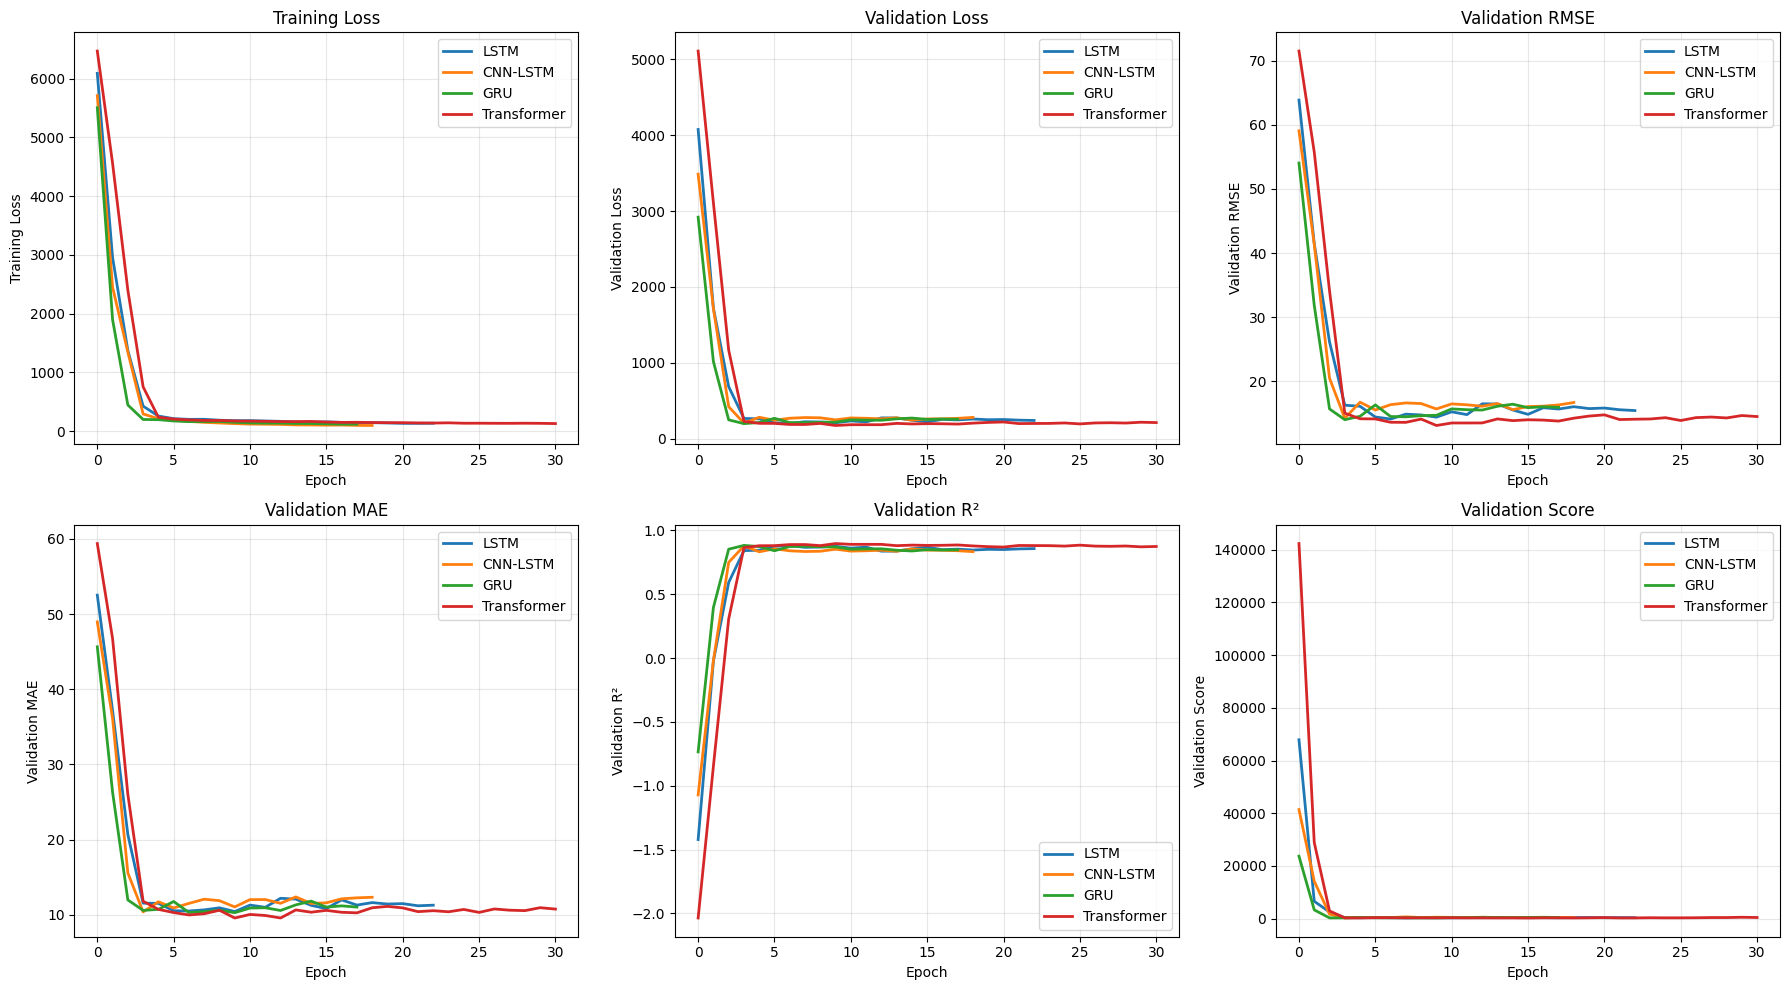

In [21]:
# Cell: Compare Model Performance
def plot_training_history(histories, model_names):
    """Plot training histories for multiple models"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    metrics = ['train_loss', 'val_loss', 'val_rmse', 'val_mae', 'val_r2', 'val_score']
    titles = ['Training Loss', 'Validation Loss', 'Validation RMSE', 
              'Validation MAE', 'Validation R²', 'Validation Score']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        row = idx // 3
        col = idx % 3
        
        for history, name in zip(histories, model_names):
            axes[row, col].plot(history[metric], label=name, linewidth=2)
        
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel(title)
        axes[row, col].set_title(title)
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/visualizations/training_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot comparison
histories = [lstm_history, cnn_lstm_history, gru_history, transformer_history]
model_names = ['LSTM', 'CNN-LSTM', 'GRU', 'Transformer']

plot_training_history(histories, model_names)

In [26]:
# Cell: Evaluate All Models
def evaluate_all_models(models, model_names, test_loader, device):
    """Evaluate and compare all models"""
    results = []
    
    criterion = nn.MSELoss()
    
    for model, name in zip(models, model_names):
        # Load best model
        model_file_name = name.lower().replace('-', '_')
        checkpoint = torch.load(f'../outputs/saved_models/{model_file_name}_model_best.pth', weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        
        # Evaluate
        metrics, predictions, actuals = evaluate(model, test_loader, criterion, device)
        
        results.append({
            'Model': name,
            'RMSE': metrics['rmse'],
            'MAE': metrics['mae'],
            'R²': metrics['r2'],
            'Score': metrics['score']
        })
        
        print(f"\n{name} Results:")
        print(f"  RMSE: {metrics['rmse']:.4f}")
        print(f"  MAE: {metrics['mae']:.4f}")
        print(f"  R²: {metrics['r2']:.4f}")
        print(f"  NASA Score: {metrics['score']:.2f}")
    
    results_df = pd.DataFrame(results)
    return results_df

models = [model, cnn_lstm_model, gru_model, transformer_model]
results_df = evaluate_all_models(models, model_names, test_loader, device)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))


LSTM Results:
  RMSE: 14.8993
  MAE: 10.6373
  R²: 0.8681
  NASA Score: 289.12

CNN-LSTM Results:
  RMSE: 14.2622
  MAE: 10.3678
  R²: 0.8792
  NASA Score: 312.29

GRU Results:
  RMSE: 15.7157
  MAE: 11.9571
  R²: 0.8533
  NASA Score: 289.92

Transformer Results:
  RMSE: 14.0278
  MAE: 10.5713
  R²: 0.8831
  NASA Score: 255.52

MODEL COMPARISON
      Model      RMSE       MAE       R²      Score
       LSTM 14.899286 10.637284 0.868128 289.117645
   CNN-LSTM 14.262179 10.367811 0.879165 312.288574
        GRU 15.715651 11.957095 0.853281 289.923615
Transformer 14.027816 10.571255 0.883104 255.524063


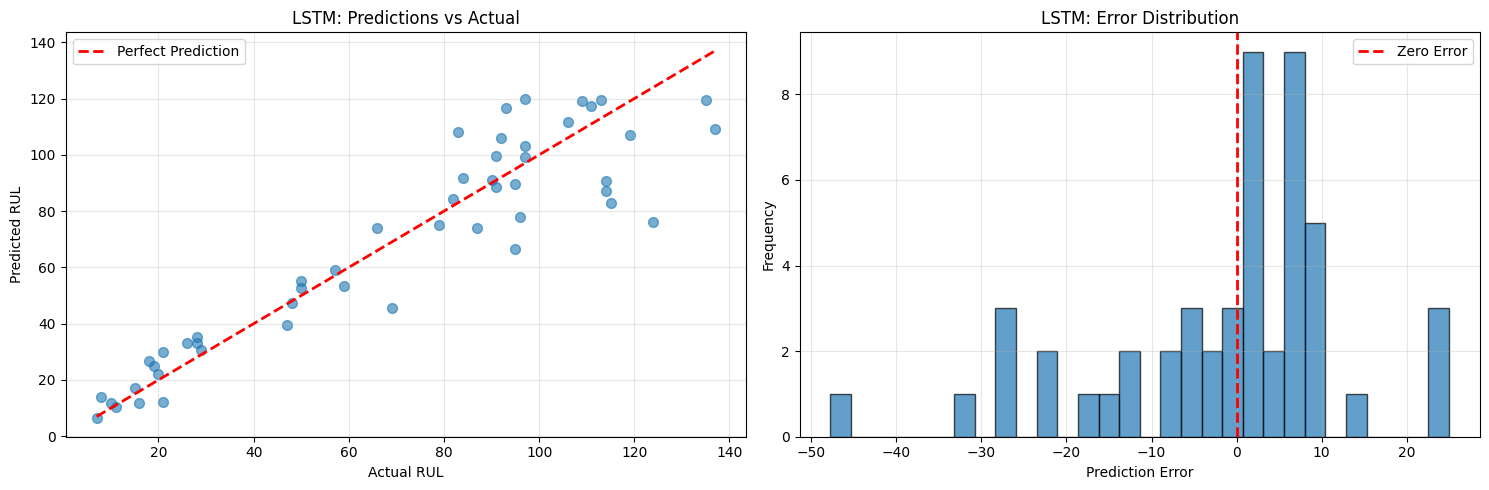

In [27]:
# Cell: Visualize Predictions
def plot_predictions(model, test_loader, device, model_name, num_samples=50):
    """Plot predictions vs actual values"""
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data).squeeze()
            predictions.extend(output.cpu().numpy())
            actuals.extend(target.cpu().numpy())
    
    predictions = np.array(predictions)[:num_samples]
    actuals = np.array(actuals)[:num_samples]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Predictions vs Actuals
    axes[0].scatter(actuals, predictions, alpha=0.6, s=50)
    axes[0].plot([actuals.min(), actuals.max()], 
                 [actuals.min(), actuals.max()], 
                 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual RUL')
    axes[0].set_ylabel('Predicted RUL')
    axes[0].set_title(f'{model_name}: Predictions vs Actual')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Error distribution
    errors = predictions - actuals
    axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    axes[1].set_xlabel('Prediction Error')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{model_name}: Error Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../outputs/visualizations/{model_name.lower()}_predictions.png', 
                dpi=300, bbox_inches='tight')
    plt.show()

# Plot for best model (e.g., LSTM)
plot_predictions(model, test_loader, device, 'LSTM')

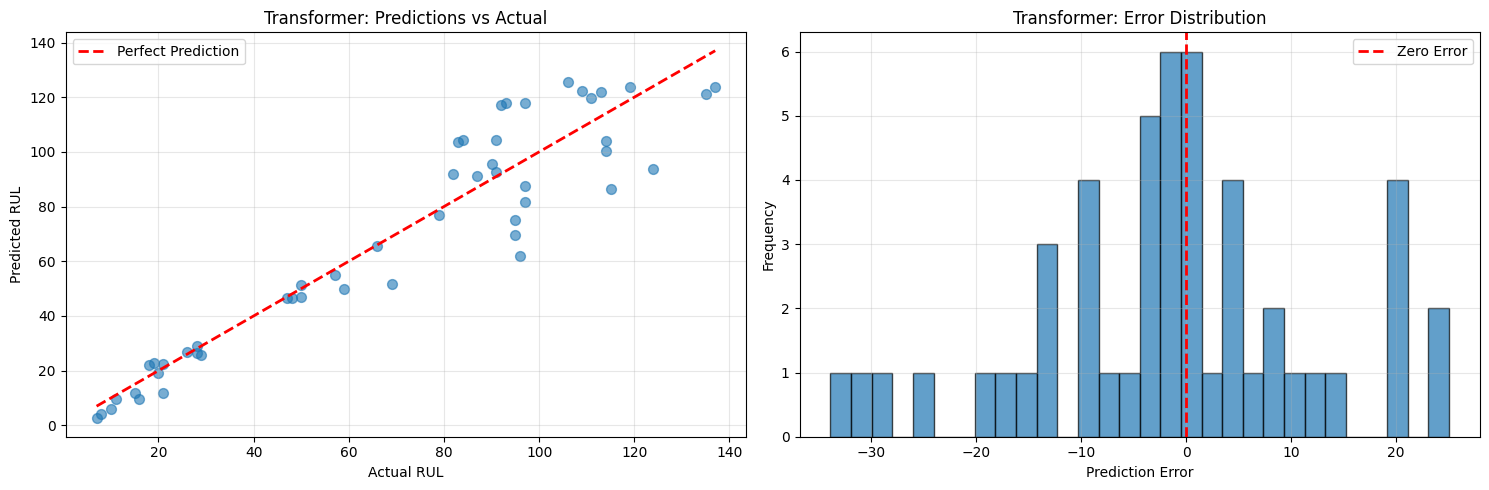

In [28]:
plot_predictions(transformer_model, test_loader, device, 'Transformer')

In [29]:
# Cell: Save Results Summary
summary = {
    'dataset': 'CMAPSS FD001',
    'sequence_length': sequence_length,
    'num_features': len(feature_cols),
    'feature_cols': feature_cols,
    'train_samples': len(train_dataset),
    'test_samples': len(test_dataset),
    'model_results': results_df.to_dict('records'),
    'best_model': results_df.loc[results_df['Score'].idxmin(), 'Model']
}

# Save to file
os.makedirs('../outputs/reports', exist_ok=True)
with open('../outputs/reports/model_comparison_summary.pkl', 'wb') as f:
    pickle.dump(summary, f)

print("Summary saved successfully!")
print(f"\nBest Model: {summary['best_model']}")

Summary saved successfully!

Best Model: Transformer
